# **Linear regression**

Marek Šugár

Analysis used implement simple <code>linear regression</code> for the purposes of predicting next-day's stock closing price.

We use scaling of all features to nomalized mean and variance and no feature selection.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error

# ML Stuff
from sklearn.linear_model import LinearRegression

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **Linear regression**

a.k.a. plain and simple :)

In [ ]:
performance_tracker = {}
performance_mean = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 8 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_mean[ticker] = []

    MAPEs = []
    AccuracyMean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        Training_Features = TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))

        which_better = mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]) >= mean_absolute_percentage_error(Test_Target, prediction)
        AccuracyMean.append(which_better)

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
    
    performance_mean[ticker] = AccuracyMean.copy()
    performance_tracker[ticker] = MAPEs.copy()

In [4]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [5]:
mean_benchmark = {}
for ticker in tickers["Ticker"]:
    mean_benchmark[ticker] = 100*np.mean(performance_mean[ticker])

mean_benchmark = dict(sorted(mean_benchmark.items(), key=lambda x: x[1]))

In [6]:
np.mean(list(mean_performances.values()))

np.float64(2.959272230535815)

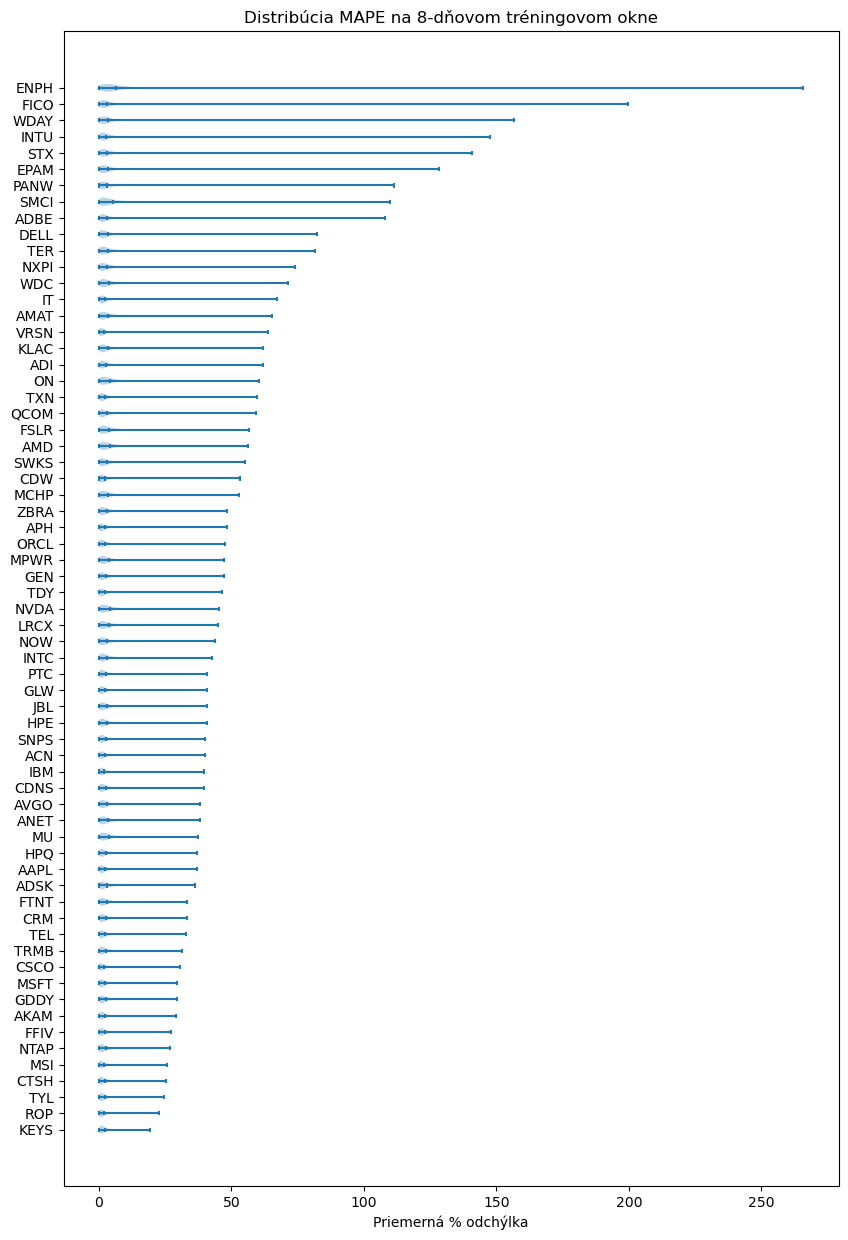

In [10]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [9]:
mean_performances

{'ROP': np.float64(1.798138271480629),
 'CSCO': np.float64(1.8921046929098184),
 'MSI': np.float64(1.8978481132438965),
 'VRSN': np.float64(1.9814367230403243),
 'IBM': np.float64(2.0242832515250653),
 'MSFT': np.float64(2.1289277517070726),
 'CTSH': np.float64(2.1660780805806774),
 'APH': np.float64(2.171681355122135),
 'TDY': np.float64(2.173726521206085),
 'ACN': np.float64(2.183113390254386),
 'TYL': np.float64(2.2457895613219234),
 'FFIV': np.float64(2.260063585434103),
 'AKAM': np.float64(2.2774047737732834),
 'TEL': np.float64(2.2774354395414536),
 'KEYS': np.float64(2.35249693439339),
 'AAPL': np.float64(2.355109154944127),
 'CDW': np.float64(2.3744519874732335),
 'GLW': np.float64(2.4303244724864506),
 'TXN': np.float64(2.4450278399319894),
 'ORCL': np.float64(2.445985401252324),
 'IT': np.float64(2.4636144948378877),
 'GDDY': np.float64(2.555958154736696),
 'PTC': np.float64(2.57947384542983),
 'GEN': np.float64(2.5977956559739277),
 'ADI': np.float64(2.637263202445303),
 'HP